In [64]:
# using Pkg; Pkg.instantiate() # if error, resets config; delete Manifest.toml first, then run this code
using Revise
using Printf
using LinearAlgebra
using PyPlot
using FFTW
using MultiModeNoise
using NPZ

# Setting up initial conditions

In [65]:
λ0 = 850e-9 # m
M = 1 # number of sp modes
Nt = 2^12 # 2^10, frequency bins
time_window = 10 # ps, range of pulse
β_order = 7; # mode order: 0, 1, 2, ...


# User Defined gammas and betas (ONLY FOR SINGLE MODE)
# gamma_user = 0.045
# betas_user = [-2e-26, 1.0e-40]  #SI units

gamma_user = 0.045 * 0  # W^-1 m^-1
betas_user = [
    -1.276e-26,   # β₂  (s^2/m)
     8.119e-41,   # β₃  (s^3/m)
    -1.321e-55,   # β₄  (s^4/m)
     3.032e-70,   # β₅  (s^5/m)
    -4.196e-85,   # β₆  (s^6/m)
     2.570e-100   # β₇  (s^7/m)
] * 0

# simulation params
sim = MultiModeNoise.get_disp_sim_params(λ0, M, Nt, time_window, β_order); # sim = dictionary of params from inputs from helpers.jl

L_fiber = 0.1 # m
radius = 4 # micron
core_NA = 0.16
alpha = 1000 #2.08 # GRIN fiber parabola param.
nx = 200 # spatial dir resolution
# fiber_fname = @sprintf("../fibers/DispersiveFiber_GRIN_r=%.2f_M=%d_λ0=%.2fum_Nt=%d_time_window=%.2fps_nx=%d_Nbeta=%d.npz", radius, M, 1e6*λ0,
#     Nt, time_window, nx, β_order+1)


# fiber params
# fiber = MultiModeNoise.get_disp_fiber_params(L_fiber, radius, core_NA, alpha, nx, sim, fiber_fname; fR=0.18, gamma_user=gamma_user, betas_user=betas_user)

fiber = MultiModeNoise.get_disp_fiber_params_user_defined(L_fiber, sim; fR=0.18, gamma_user=gamma_user, betas_user=betas_user)

fiber["zsave"] = LinRange(0, L_fiber, 101); # resolution in z, =linspace(start,stop,length) but lazy until collected
# fiber["zsave"] = LinRange(0, L_fiber, 11);
# fiber["zsave"] = nothing # no propagation results save in the mid points

P_cont = 0.01 # W
pulse_fwhm = 50e-15 # s
pulse_rep_rate = 20e6 # Hz

println("Peak Power: ", P_cont/(pulse_fwhm * pulse_rep_rate))

# u0_modes = normalize([0.4, 0.1, 0.0])
# u0_modes = normalize([0.01, 0.5, 0.5])
# u0_modes = normalize([1, -7, 2])
# u0_modes = normalize([0.3047514842181003 - 0.1212176801553783im, -0.19527485778306808 - 0.17258465757219718im, 0.1257224577684066 + 0.24229927029558837im]) # from running Michael's cw optimization code
# println(abs2.(u0_modes)) # print new line, element-wise abs^2
u0_modes = [1]

ut0, uω0 = MultiModeNoise.get_initial_state(u0_modes, P_cont, pulse_fwhm, pulse_rep_rate, "sech_sq", sim); # initial state [Nt x M]

User defined fiber params
[0.0; 0.0; -0.0; 0.0; -0.0; 0.0; -0.0; 0.0;;]
Peak Power: 10000.0


In [66]:
println(fiber["γ"])
println(summary(fiber["γ"]))
# println(fiber["betas"])
# println(summary(fiber["betas"]))
println(summary(uω0))
# print(summary([0.0; 0.0; betas_user;;]))

[0.0;;;;]
1×1×1×1 Array{Float64, 4}
4096×1 Matrix{ComplexF64}


# Testing Gain Stuff

In [67]:
# gain_params = MultiModeNoise.get_ydfa_cross_sections(sim["fs"])

# # Create a plot in frequency
# fig = figure(figsize=(8, 5))
# # plot(sim["ts"]*1e15,ut0)
# plot(sim["fs"], gain_params["sigma_as"] * 1e24)
# plot(sim["fs"], gain_params["sigma_es"] * 1e24)
# xlim(3e8/1100 * 1e-12 * 1e9, 3e8/1000 * 1e-12 * 1e9)
# # ylim(0, 1000)
# fig

# Fiber propagation through L

In [68]:
# fiber["gain_parameters"] = MultiModeNoise.get_YDFAParams(sim)
fiber["gain_parameters"] = 3.0
@time sol_disp_mmf = MultiModeNoise.solve_disp_gain_smf(uω0, fiber, sim, pump_power=0.6);

  0.035087 seconds (5.47 k allocations: 60.748 MiB)


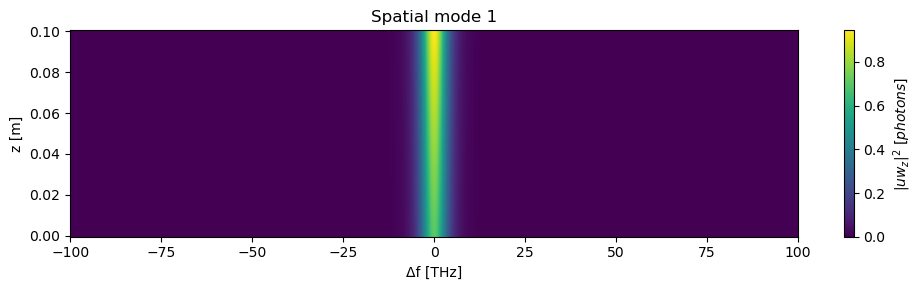

In [69]:
uω_z = sol_disp_mmf["uω_z"]; # uω_z = [L x Nt x M] = [fiber length, time point, spatial modes]

FF, ZZ = MultiModeNoise.meshgrid(sim["fs"] .- sim["f0"], fiber["zsave"]) # create meshgrid for plotting; fs: stop freq, f0: start freq (THz)

fig, axs = subplots(1, M, figsize=(10,3))

if M == 1
    axs = [axs] # Wrap the single object in a list
end

for i in 1:M 
    im = axs[i].pcolormesh(FF, ZZ, abs2.(fftshift(uω_z[:,:,i], 2)) , shading="nearest") # plotting for every sp mode
    fig.colorbar(im, ax=axs[i], label=L"|uw_z|^2\ [photons]") # number of photons; photon-number-normalized power-like quantity (uw_z=sqrt(Nt*dt/hbar/omega0)*Aw_z); Aw_z = [sqrt(power)]
    axs[i].set_title(@sprintf("Spatial mode %d",i))
    axs[i].set_xlim(-100,100)
    axs[i].set_xlabel("Δf [THz]")
    axs[i].set_ylabel("z [m]")
end
fig.tight_layout()
fig

normalize the above color scheme with $\epsilon$ and $N_t$ properly: $u_w(z)\times\sqrt{N_t\epsilon}$

Plotting before and after

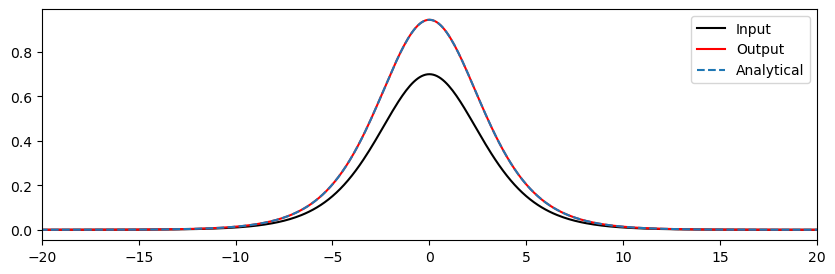

In [70]:
fig2, axs2 = subplots(1, M, figsize=(10, 3))
if M == 1
    axs2 = [axs2] # Wrap the single object in a list
end

for i in 1:M
    im = axs2[i].plot(FF[1, :], abs2.(fftshift(uω_z[1,:,i])), color="black", label="Input")
    im = axs2[i].plot(FF[1, :], abs2.(fftshift(uω_z[end,:,i])), color="red", label="Output")
    im = axs2[i].plot(FF[1, :], abs2.(fftshift(uω_z[1,:,i])) * exp(3 .* L_fiber), label="Analytical", "--")
    axs2[i].set_xlim(-20,20)
end
legend()
fig2

# Plotting Wavelength

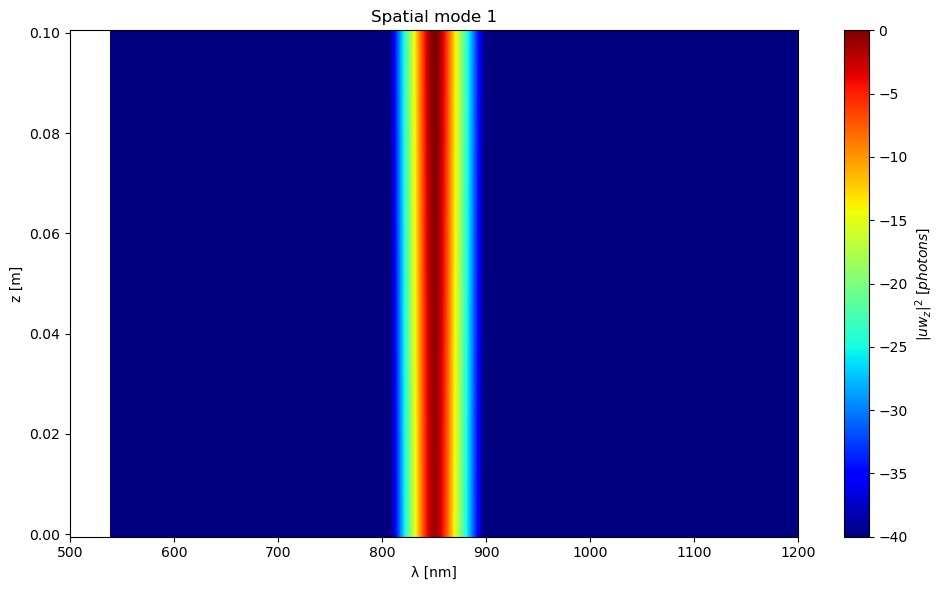

In [71]:
uω_z = sol_disp_mmf["uω_z"]; # uω_z = [L x Nt x M] = [fiber length, time point, spatial modes]

ΛΛ, ZZ = MultiModeNoise.meshgrid(3e8./sim["fs"] * 1e-3, fiber["zsave"]) # create meshgrid for plotting; fs: stop freq, f0: start freq (THz)

fig, axs = subplots(1, M, figsize=(10,6))

if M == 1
    axs = [axs] # Wrap the single object in a list
end

for i in 1:M 

    P = abs2.(fftshift(uω_z[:,:,i], 2))          # linear photons
    P_dB = 10 .* log10.(P ./ maximum(P))

    im = axs[i].pcolormesh(ΛΛ, ZZ, P_dB, shading="nearest", vmin=-40, cmap="jet") # plotting for every sp mode
    fig.colorbar(im, ax=axs[i], label=L"|uw_z|^2\ [photons]") # number of photons; photon-number-normalized power-like quantity (uw_z=sqrt(Nt*dt/hbar/omega0)*Aw_z); Aw_z = [sqrt(power)]
    axs[i].set_title(@sprintf("Spatial mode %d",i))
    axs[i].set_xlim(500,1200)
    axs[i].set_xlabel("λ [nm]")
    axs[i].set_ylabel("z [m]")
end
fig.tight_layout()
fig

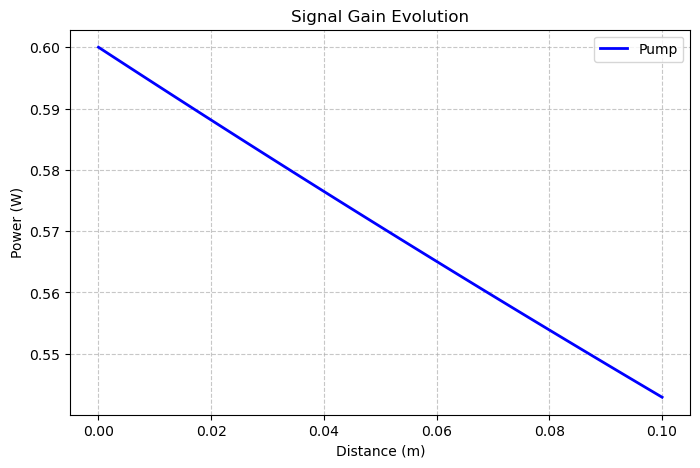

In [72]:
# # Power loss for pump
Pp_z = sol_disp_mmf["Ppz"]; # pump power along fiber

# 3. Create the plot
fig = figure(figsize=(8, 5))

# Plot Signal and PUmp power over length
# plot(z_save, Ps_raw, label="Signal", color="red", linewidth=2)
plot(fiber["zsave"], Pp_z, label="Pump", color="blue", linewidth=2)
# plot(fiber["zsave"], Ps_z, label="Signal", color="red", linewidth=2)

# 4. Formatting
title("Signal Gain Evolution")
xlabel("Distance (m)")
ylabel("Power (W)") # Changed from Power (W) to Gain (dB)
# ylim(-10, 40)
grid(true, linestyle="--", alpha=0.7)
legend()

fig